<a href="https://colab.research.google.com/github/Neural-forge9/CanvasPilot/blob/main/PyCaret_for_Regression_with_Results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Experiment 5: Develop a prediction model based on linear/logistic regression.

Software Used: Google Colab

---
# **PyCaret for Regression**
---
- It is a bundle of many Machine Learning algorithms.
- Only three lines of code is required to compare 20 ML models.
- Pycaret is available for:
    - Classification
    - Regression
    - Clustering

---

### **Self Learning Resource**
1. Tutorial on Pycaret <a href="https://pycaret.readthedocs.io/en/latest/tutorials.html"> Click Here</a>

2. Documentation on Pycaret-Regression: <a href="https://pycaret.org/regression/"> Click Here </a>

---

### **In this experiment we will learn:**

- Getting Data: How to import data from PyCaret repository
- Setting up Environment: How to setup an experiment in PyCaret and get started with building regression models
- Create Model: How to create a model, perform cross validation and evaluate regression metrics
- Tune Model: How to automatically tune the hyperparameters of a regression model
- Plot Model: How to analyze model performance using various plots
- Finalize Model: How to finalize the best model at the end of the experiment
- Predict Model: How to make prediction on new / unseen data
- Save / Load Model: How to save / load a model for future use

---



#### **(a) Install Pycaret**

In [ ]:
!pip install pycaret &> /dev/null
print ("Pycaret installed sucessfully!!")

Pycaret installed sucessfully!!


#### **(b) Get the version of the pycaret**

In [ ]:
from pycaret.utils import version
version()

'2.3.1'

---
# **1. Regression: Basics**
---

### **1.1 Loading Dataset - Loading dataset from pycaret**

In [ ]:
from pycaret.datasets import get_data

# No output

---
### **1.2 Get the list of datasets available in pycaret (55)**
---

In [ ]:
# Internet connection is required
dataSets = get_data('index')

---
### **1.3 Get boston dataset**
---

In [ ]:
bostonDataSet = get_data("boston")    # SN is 46
# This is regression dataset. The values in medv are continuous values

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


Read data from file

In [ ]:
# import pandas as pd
# bostonDataSet = pd.read_csv("myFile.csv")

---
### **1.4 Parameter setting for all regression models**
- Train/Test division
- Sampling
- Normalization
- Transformation
- PCA (Dimention Reduction)
- Handaling of Outliers
- Feature Selection
---

In [ ]:
from pycaret.regression import *
s = setup(data =  bostonDataSet, target='medv', silent=True)

,Description,Value
0,session_id,5990
1,Target,medv
2,Original Data,"(506, 14)"
3,Missing Values,False
4,Numeric Features,11
5,Categorical Features,2
6,Ordinal Features,False
7,High Cardinality Features,False
8,High Cardinality Method,None
9,Transformed Train Set,"(354, 21)"


---
### **1.5 Run and compare the Model Performance**
---

In [ ]:
cm = compare_models()
# Explore more parameters

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,2.0613,8.1297,2.8212,0.8894,0.1294,0.1044,0.453
gbr,Gradient Boosting Regressor,2.1592,8.4285,2.8664,0.8855,0.1371,0.1115,0.105
rf,Random Forest Regressor,2.2189,9.3748,3.0165,0.8714,0.1394,0.1128,0.515
lightgbm,Light Gradient Boosting Machine,2.2592,9.4285,3.0302,0.8664,0.1392,0.1155,0.084
ada,AdaBoost Regressor,2.5230,10.3433,3.1880,0.8613,0.1549,0.1321,0.104
lr,Linear Regression,3.2945,21.0884,4.5153,0.7216,0.2376,0.1663,0.286
lar,Least Angle Regression,3.2945,21.0884,4.5153,0.7216,0.2376,0.1663,0.017
ridge,Ridge Regression,3.2726,21.2156,4.5258,0.7192,0.2347,0.1655,0.014
br,Bayesian Ridge,3.2758,21.5010,4.5527,0.7148,0.2321,0.1657,0.015
dt,Decision Tree Regressor,3.1813,21.2463,4.4930,0.7142,0.2031,0.1622,0.019


---
### **1.6 Three line of code for model comparison for "Insurance" dataset**
---

In [ ]:
from pycaret.datasets import get_data
from pycaret.regression import *

insuranceDataSet = get_data("insurance")
s = setup(data = insuranceDataSet, target='charges', silent=True)
cm = compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,2568.8559,2.161525e+07,4599.2621,0.8441,0.4427,0.3128,0.097
lightgbm,Light Gradient Boosting Machine,2879.2645,2.418949e+07,4871.2422,0.8252,0.5807,0.3678,0.054
rf,Random Forest Regressor,2816.7217,2.507134e+07,4978.4168,0.8193,0.4909,0.3571,0.567
ada,AdaBoost Regressor,3863.9708,2.597083e+07,5069.8902,0.8146,0.6072,0.6649,0.031
et,Extra Trees Regressor,2822.0495,2.866991e+07,5327.8216,0.7925,0.5072,0.3538,0.498
llar,Lasso Least Angle Regression,4174.3554,3.696391e+07,6053.4100,0.7353,0.5521,0.4248,0.018
lasso,Lasso Regression,4177.1673,3.699678e+07,6055.6541,0.7350,0.5656,0.4246,0.016
ridge,Ridge Regression,4189.9187,3.699883e+07,6056.2137,0.7350,0.5750,0.4270,0.014
br,Bayesian Ridge,4186.7510,3.700160e+07,6056.3330,0.7350,0.5654,0.4264,0.015
lr,Linear Regression,4177.0151,3.700521e+07,6056.2999,0.7349,0.5682,0.4245,0.014


---
### **1.7 Three line of code for model comparison for "House" dataset**
---

In [ ]:
from pycaret.datasets import get_data
from pycaret.regression import *

houseDataSet = get_data("house")
s = setup(data = houseDataSet, target='SalePrice', silent=True)
cm = compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,1.772298e+04,9.211010e+08,2.845651e+04,8.623000e-01,0.1397,0.1033,0.773
lightgbm,Light Gradient Boosting Machine,1.795046e+04,1.011700e+09,3.045307e+04,8.520000e-01,0.1463,0.1037,0.241
rf,Random Forest Regressor,1.933630e+04,1.106446e+09,3.176462e+04,8.354000e-01,0.1610,0.1154,2.429
omp,Orthogonal Matching Pursuit,1.822468e+04,1.375951e+09,3.349238e+04,8.003000e-01,0.1835,0.1070,0.040
ridge,Ridge Regression,1.951864e+04,1.444908e+09,3.463053e+04,7.841000e-01,0.1661,0.1151,0.063
ada,AdaBoost Regressor,2.608471e+04,1.421018e+09,3.710017e+04,7.770000e-01,0.2143,0.1731,0.497
lasso,Lasso Regression,2.035012e+04,1.578682e+09,3.625400e+04,7.629000e-01,0.2577,0.1246,0.209
et,Extra Trees Regressor,2.265854e+04,1.505368e+09,3.791066e+04,7.613000e-01,0.1814,0.1310,2.618
en,Elastic Net,2.160428e+04,1.762178e+09,3.834992e+04,7.365000e-01,0.1694,0.1254,0.216
lr,Linear Regression,2.456054e+04,2.015680e+09,4.197928e+04,6.879000e-01,0.2729,0.1541,0.057


---
# **2. Regression: Advance - 1**
---

#### **2.1 Model Performance using data "Normalization"**

In [ ]:
s = setup(data = bostonDataSet, target = 'medv', normalize = True, normalize_method = 'zscore', silent=True)
cm = compare_models()

#normalize_method = {zscore, minmax, maxabs, robust}

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,2.2525,11.9173,3.3506,0.8395,0.1465,0.1126,0.460
gbr,Gradient Boosting Regressor,2.3759,11.6138,3.3821,0.8360,0.1540,0.1196,0.108
rf,Random Forest Regressor,2.3712,12.2982,3.4668,0.8345,0.1526,0.1187,0.533
lightgbm,Light Gradient Boosting Machine,2.4575,14.0266,3.6759,0.8106,0.1575,0.1201,0.040
ada,AdaBoost Regressor,2.8419,15.9846,3.9552,0.7868,0.1827,0.1504,0.105
knn,K Neighbors Regressor,2.8686,18.8237,4.2184,0.7562,0.1772,0.1360,0.063
br,Bayesian Ridge,3.3239,23.6952,4.7831,0.6908,0.2512,0.1631,0.016
huber,Huber Regressor,3.2271,24.9734,4.8413,0.6881,0.2542,0.1536,0.029
ridge,Ridge Regression,3.3637,23.7857,4.7967,0.6879,0.2510,0.1648,0.014
lr,Linear Regression,3.3842,23.9159,4.8113,0.6856,0.2517,0.1659,0.015


---
### **2.2 Model Performance using "Feature Selection"**
---

In [ ]:
s = setup(data = bostonDataSet, target = 'medv', feature_selection = True, feature_selection_threshold = 0.9, silent=True)
cm = compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,2.2333,11.5437,3.2768,0.8404,0.1501,0.1150,0.444
gbr,Gradient Boosting Regressor,2.2487,11.6528,3.2693,0.8366,0.1531,0.1170,0.097
rf,Random Forest Regressor,2.3575,13.5977,3.5407,0.8144,0.1580,0.1202,0.510
lightgbm,Light Gradient Boosting Machine,2.4635,13.6660,3.5955,0.8121,0.1621,0.1258,0.039
ada,AdaBoost Regressor,2.7269,16.6389,3.9934,0.7680,0.1804,0.1436,0.093
dt,Decision Tree Regressor,3.0496,21.5964,4.5034,0.7143,0.2070,0.1587,0.017
lr,Linear Regression,3.4893,25.6676,4.9208,0.6717,0.2527,0.1763,0.013
ridge,Ridge Regression,3.4693,25.8383,4.9294,0.6715,0.2636,0.1767,0.014
br,Bayesian Ridge,3.5185,26.6405,5.0119,0.6618,0.2703,0.1793,0.014
en,Elastic Net,3.8338,31.0114,5.4287,0.6055,0.2758,0.1839,0.014


---
### **2.3 Model Performance using "Outlier Removal"**
---

In [ ]:
s = setup(data = bostonDataSet, target = 'medv', remove_outliers = True, outliers_threshold = 0.05, silent=True)
cm = compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,1.9469,7.9527,2.7527,0.8827,0.1265,0.0990,0.451
gbr,Gradient Boosting Regressor,2.0667,9.4401,2.8955,0.8661,0.1373,0.1068,0.091
rf,Random Forest Regressor,2.1141,9.9440,2.9692,0.8575,0.1396,0.1104,0.509
lightgbm,Light Gradient Boosting Machine,2.1797,10.6409,3.0521,0.8502,0.1348,0.1090,0.039
ada,AdaBoost Regressor,2.5725,13.3359,3.5250,0.8064,0.1628,0.1339,0.092
dt,Decision Tree Regressor,2.8802,17.5934,3.9450,0.7490,0.1889,0.1490,0.016
ridge,Ridge Regression,2.9756,17.5036,4.0487,0.7473,0.2205,0.1533,0.013
lr,Linear Regression,2.9833,17.5430,4.0532,0.7469,0.2225,0.1538,0.013
br,Bayesian Ridge,2.9701,17.6438,4.0684,0.7445,0.2147,0.1524,0.014
lar,Least Angle Regression,3.2810,21.4263,4.4838,0.6764,0.2442,0.1690,0.017


---
### **2.4 Model Performance using "Transformation"**
---

In [ ]:
s = setup(data = bostonDataSet, target = 'medv', transformation = True, transformation_method = 'yeo-johnson', silent=True)
cm = compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,2.1953,8.3473,2.8497,0.8819,0.1444,0.1161,0.092
rf,Random Forest Regressor,2.2168,9.1829,2.9570,0.8795,0.1439,0.1163,0.501
et,Extra Trees Regressor,2.1738,9.8099,2.9943,0.8766,0.1379,0.1100,0.450
ada,AdaBoost Regressor,2.5934,11.0381,3.2612,0.8468,0.1688,0.1419,0.094
lightgbm,Light Gradient Boosting Machine,2.4271,12.1036,3.3776,0.8467,0.1595,0.1257,0.040
knn,K Neighbors Regressor,2.8261,17.2318,4.0407,0.7684,0.1809,0.1419,0.062
dt,Decision Tree Regressor,2.8962,16.6474,3.9897,0.7658,0.1931,0.1523,0.015
br,Bayesian Ridge,3.3157,20.4448,4.4028,0.7488,0.2177,0.1746,0.014
ridge,Ridge Regression,3.3548,20.5828,4.4250,0.7463,0.2192,0.1765,0.014
lar,Least Angle Regression,3.3750,20.6475,4.4360,0.7450,0.2200,0.1774,0.017


---
### **2.5 Model Performance using "PCA"**
---

In [ ]:
s = setup(data = bostonDataSet, target = 'medv', pca = True, pca_method = 'linear', silent=True)
cm = compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,4.7579,50.1766,6.9202,0.3842,0.2812,0.2364,0.434
lightgbm,Light Gradient Boosting Machine,4.8950,50.6940,6.9594,0.3747,0.2826,0.2395,0.030
gbr,Gradient Boosting Regressor,4.7525,52.1176,6.9834,0.3685,0.2827,0.2365,0.058
knn,K Neighbors Regressor,4.8988,50.4595,7.0002,0.3616,0.2829,0.2418,0.061
et,Extra Trees Regressor,4.8876,54.2282,7.1564,0.3354,0.2892,0.2445,0.409
lr,Linear Regression,5.3394,58.2617,7.4706,0.2877,0.2995,0.2579,0.014
ridge,Ridge Regression,5.3394,58.2617,7.4706,0.2877,0.2995,0.2579,0.013
lar,Least Angle Regression,5.3394,58.2617,7.4706,0.2877,0.2995,0.2579,0.014
lasso,Lasso Regression,5.3410,58.2647,7.4711,0.2876,0.2996,0.2580,0.015
en,Elastic Net,5.3403,58.2628,7.4709,0.2876,0.2995,0.2580,0.014


---
### **2.6 Model Performance using "Outlier Removal" + "Normalization"**
---

In [ ]:
s = setup(data = bostonDataSet, target = 'medv', remove_outliers = True, outliers_threshold = 0.05, normalize = True, normalize_method = 'zscore', silent=True)
cm = compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,2.0944,9.5989,2.9828,0.8770,0.1411,0.1076,0.449
gbr,Gradient Boosting Regressor,2.2069,9.8574,3.0758,0.8706,0.1483,0.1155,0.091
rf,Random Forest Regressor,2.2991,11.6036,3.2677,0.8537,0.1533,0.1187,0.500
lightgbm,Light Gradient Boosting Machine,2.4453,12.5609,3.4327,0.8446,0.1595,0.1251,0.039
ada,AdaBoost Regressor,2.7620,14.8197,3.7711,0.8060,0.1834,0.1507,0.093
dt,Decision Tree Regressor,3.1009,19.4040,4.2898,0.7403,0.2175,0.1684,0.017
knn,K Neighbors Regressor,3.0696,23.4017,4.5924,0.7349,0.1794,0.1380,0.061
br,Bayesian Ridge,3.4865,24.7083,4.8472,0.6969,0.2462,0.1742,0.013
ridge,Ridge Regression,3.5338,24.7467,4.8591,0.6946,0.2504,0.1764,0.014
lr,Linear Regression,3.5521,24.8497,4.8733,0.6925,0.2530,0.1772,0.012


---
### **2.7 Model Performance using "Outlier Removal" + "Normalization" + "Transformation"**
---

In [ ]:
s = setup(data = bostonDataSet, target = 'medv', remove_outliers = True, outliers_threshold = 0.05, normalize = True, normalize_method = 'zscore', transformation = True, transformation_method = 'yeo-johnson', silent=True)
cm = compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,2.0459,9.2277,2.9296,0.8554,0.1313,0.1032,0.444
gbr,Gradient Boosting Regressor,2.1264,10.3774,3.1065,0.8288,0.1449,0.1107,0.090
rf,Random Forest Regressor,2.2446,11.2221,3.2544,0.8208,0.1440,0.1127,0.511
lightgbm,Light Gradient Boosting Machine,2.3255,12.0976,3.3920,0.8115,0.1427,0.1117,0.038
ada,AdaBoost Regressor,2.8007,15.4455,3.8236,0.7639,0.1768,0.1490,0.097
knn,K Neighbors Regressor,2.8570,21.1692,4.4358,0.7001,0.1781,0.1345,0.062
ridge,Ridge Regression,3.3023,21.1415,4.5220,0.6801,0.2091,0.1674,0.014
br,Bayesian Ridge,3.2681,21.2289,4.5233,0.6799,0.2084,0.1659,0.014
lr,Linear Regression,3.3208,21.2061,4.5312,0.6786,0.2101,0.1683,0.015
huber,Huber Regressor,3.0957,22.4442,4.5891,0.6708,0.2079,0.1519,0.025


---
# **3. Regression: Advance - 2**
---

### **3.1 Build a single model - "RandomForest"**

In [ ]:
from pycaret.datasets import get_data
from pycaret.regression import *

bostonDataSet = get_data("boston")    # SN is 46
s = setup(data =  bostonDataSet, target='medv', silent=True)

rfModel = create_model('rf')
# Explore more parameters

,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,1.8839,7.8722,2.8057,0.9063,0.0973,0.0783
1,1.9018,4.9397,2.2225,0.9381,0.1253,0.1046
2,2.1574,9.9905,3.1608,0.8337,0.1273,0.1066
3,2.4252,11.1608,3.3408,0.8855,0.1541,0.1218
4,2.4722,8.2281,2.8685,0.9257,0.1654,0.1488
5,2.7796,13.3277,3.6507,0.8679,0.1366,0.1151
6,2.8212,25.7741,5.0768,0.7867,0.1563,0.1031
7,3.0538,29.8333,5.4620,0.6573,0.1789,0.1365
8,2.4403,18.1789,4.2637,0.7246,0.1712,0.1246
9,1.9193,8.3709,2.8933,0.8857,0.1370,0.0962


---
### **3.2 Other models**
---
```
-	'ada' - AdaBoost Regressor
-	'br' - Bayesian Ridge
-	'dt' - Decision Tree Regressor
-	'en'	- Elastic Net
-	'et' - Extra Trees Regressor
-	'gbr' - Gradient Boosting Regressor
-	'huber' - Huber Regressor
-	'knn' - K Neighbors Regressor
-	'llar' - Lasso Least Angle Regression
-	'lasso' - Lasso Regression
-	'lar' - Least Angle Regression
-	'lightgbm'	- Light Gradient Boosting Machine
-	'lr' - Linear Regression
-	'omp' - Orthogonal Matching Pursuit
-	'par' - Passive Aggressive Regressor
-	'rf' - Random Forest Regressor
-	'ridge' - Ridge Regression
```

---
### **3.3 Save the trained model**
---

In [ ]:
sm = save_model(rfModel, 'rfModelFile')

Transformation Pipeline and Model Successfully Saved


---
### **3.4 Load the model**
---

In [ ]:
rfModel = load_model('rfModelFile')

Transformation Pipeline and Model Successfully Loaded


---
### **3.5 Make prediction on the new dataset**
---

#### **Get new dataset**

In [ ]:
# Select top 10 rows from boston dataset
newDataSet = get_data("boston").iloc[:10]

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


#### **Make prediction on new dataset**

In [ ]:
newPredictions = predict_model(rfModel, data = newDataSet)
newPredictions

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv,Label
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0,25.882000
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6,22.219000
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7,36.509000
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4,33.825000
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2,35.453001
5,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222,18.7,394.12,5.21,28.7,27.844001
6,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311,15.2,395.60,12.43,22.9,21.946000
7,0.14455,12.5,7.87,0,0.524,6.172,96.1,5.9505,5,311,15.2,396.90,19.15,27.1,17.938000
8,0.21124,12.5,7.87,0,0.524,5.631,100.0,6.0821,5,311,15.2,386.63,29.93,16.5,16.513000
9,0.17004,12.5,7.87,0,0.524,6.004,85.9,6.5921,5,311,15.2,386.71,17.10,18.9,18.896000


---
### **3.6 Scatter plot b/w actual and predicted**
---

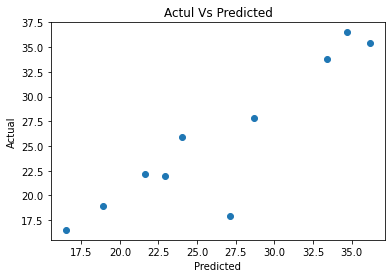

In [ ]:
import matplotlib.pyplot as plt

predicted = newPredictions.iloc[:,-1]     # Last column
actual = newPredictions.iloc[:,-2]        # 2nd last column

plt.scatter(actual, predicted)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Actul Vs Predicted')
plt.savefig("result-scatter-plot.jpg", dpi=300)
plt.show()

---
### **3.7 Save prediction results to csv**
---

In [ ]:
newPredictions.to_csv("NewPredictions.csv")
# No output

---
### **3.8 Plot the Model**
---
##### Following parameter can be plot for model
- Prediction Error Plot    - 'error'
- Learning Curve           - 'learning'
- Validation Curve         - 'vc'
- Feature Importance       - 'feature'
- Model Hyperparameter     - 'parameter'

---
##### **3.8.2 Plot Error (Scatter Plot)**
---

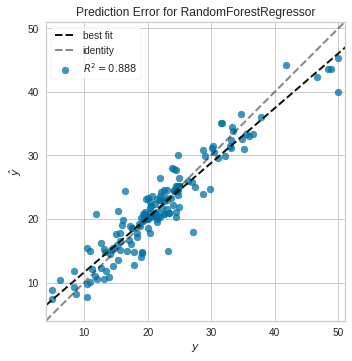

In [ ]:
plot_model(rfModel, plot='error')

---
### **3.9 Feature Importance**
---

##### **3.9.1 Feature Importance using Random Forest**

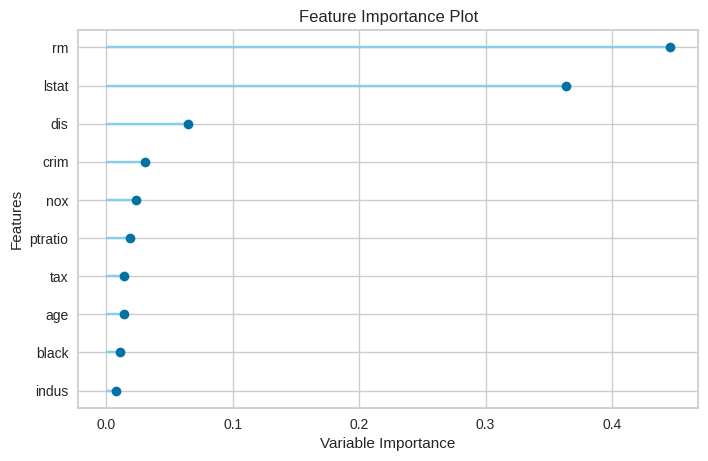

In [ ]:
rfModel = create_model('rf', verbose=False)
plot_model(rfModel, plot='feature')

---
##### **3.9.2 Feature Importance using Extra Trees Regressor**
---

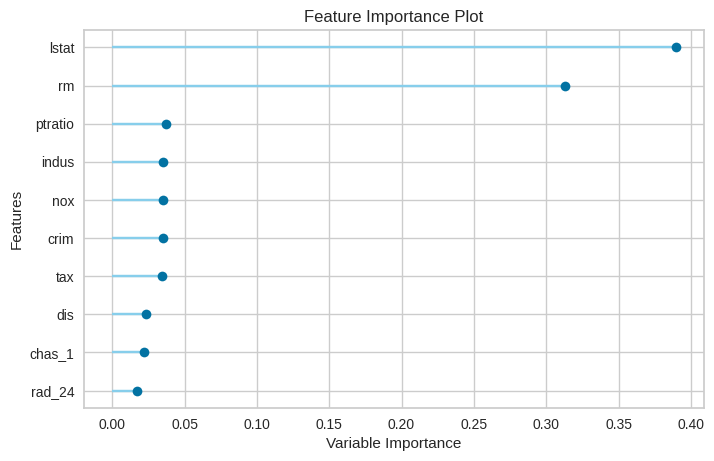

In [ ]:
etModel = create_model('et', verbose=False)
plot_model(etModel, plot='feature')

---
##### **3.9.3 Feature Importance using Decision Tree**
---

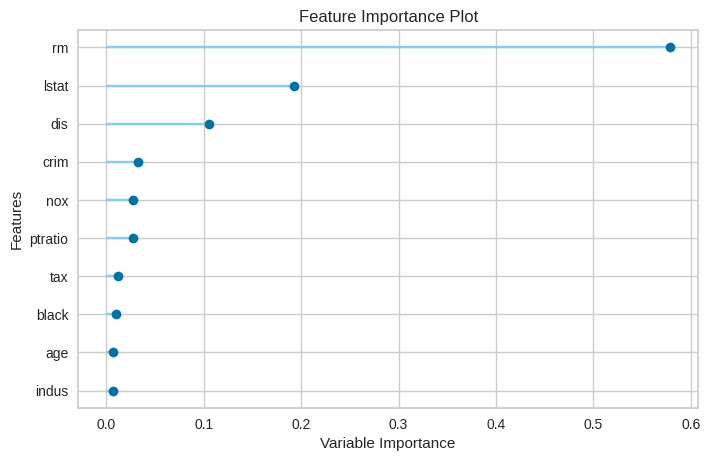

In [ ]:
dtModel = create_model('dt', verbose=False)
plot_model(dtModel, plot='feature')

#### **Self Learning Resource**

###### 1. Tutorial on Pycaret <a href="https://pycaret.readthedocs.io/en/latest/tutorials.html"> Click Here</a>

###### 2. Documentation on Pycaret-Regression: <a href="https://pycaret.org/regression/"> Click Here </a>

**Task**: Train and Develope a regression model, save and load it. Make predictions on a new dataset. Yoy can refer \"PyCaret\" for regression dataset